# Random Forest

*SPDX-FileCopyrightText: © 2026 Nina Preußler <nina.preussler@studserv.uni-leipzig.de>*

*SPDX-License-Identifier: CC BY 4.0*

*SPDX-FileContributor: Giovanna Limón <giovannalimon68@gmail.com>*

In this notebooks, we prepare, conduct, and evaluate the random forest prediction of vegetation recovery. It consists of the following sections:

- [prepare data](#Prepare-data)
- [explore distribution of recovery rates](#Distribution-of-recovery-rates)
- [explore predictor distribution](#Predictor-distribution)
- [fit the models](#Model-fitting)
- [assess model accuracy](#Model-accuracy)
- [analyze residuals](#Residual-analysis)
- [analyze variable importance scores](#Variable-importance)
- [visualize variable effects](#Variable-effects)

In [1]:
import xarray as xr
import rioxarray as rxr
import geopandas as gpd
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import PartialDependenceDisplay

## Prepare data

In [2]:
# import layers and combine in one dataset
ds = xr.Dataset({
    "study_area": rxr.open_rasterio('output-data/study-area/study_area.tif'),
    # predictors
    "hfp": rxr.open_rasterio('output-data/predictor-layers/hfp.tif'),
    "drainage_dist": rxr.open_rasterio("output-data/predictor-layers/drainage-dist.tif"),
    "forest_dist": rxr.open_rasterio("output-data/predictor-layers/forest-dist.tif"),
    "pre_fire_evi": rxr.open_rasterio("output-data/predictor-layers/evi_pre.tif"),
    'aridity_index': rxr.open_rasterio('output-data/predictor-layers/aridity_index.tif'),
    'fire_history': rxr.open_rasterio('output-data/predictor-layers/fire_count.tif'),
    'dnbr': rxr.open_rasterio('output-data/predictor-layers/dnbr.tif'),
    'elevation': rxr.open_rasterio('output-data/predictor-layers/elevation.tif'),
    # target variables
    'recovery_2y': rxr.open_rasterio("output-data/target-variables/recovery_rate_2017.tif"),
    'recovery_5y': rxr.open_rasterio("output-data/target-variables/recovery_rate_2020.tif")
})

In [3]:
# transform to pandas dataframe (only study area pixels)
df = ds.to_dataframe().reset_index()

# remove pixels outside study area
df = df[df.study_area == 1]

# reset index for proper slicing later
df = df.reset_index()

# drop unnecessary columns
df = df.drop(['index', 'band', 'spatial_ref', 'study_area'], axis='columns') 

In [4]:
# check data availability
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17989 entries, 0 to 17988
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   x              17989 non-null  float64
 1   y              17989 non-null  float64
 2   hfp            17955 non-null  float32
 3   drainage_dist  17989 non-null  float64
 4   forest_dist    17989 non-null  float64
 5   pre_fire_evi   14011 non-null  float64
 6   aridity_index  17989 non-null  float64
 7   fire_history   17989 non-null  uint16 
 8   dnbr           17989 non-null  float64
 9   elevation      17989 non-null  int16  
 10  recovery_2y    14011 non-null  float64
 11  recovery_5y    14011 non-null  float64
dtypes: float32(1), float64(9), int16(1), uint16(1)
memory usage: 1.4 MB


In [5]:
# remove rows with nans
df = df.dropna()

In [6]:
# check remaining pixels
len(df) 

13981

## Distribution of recovery rates

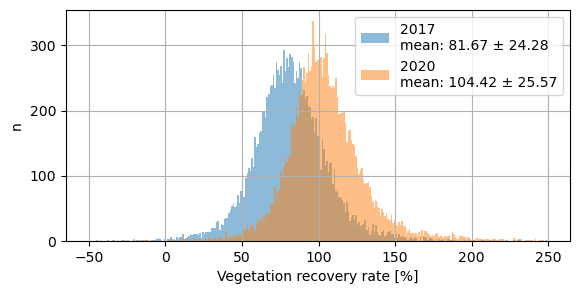

In [7]:
# histograms of predictors and target metrics

plt.subplots(figsize=(6.5,3))

# set up labels
mean_2y = df.recovery_2y.mean()
std_2y = np.std(df.recovery_2y)
label_2y = f'2017 \nmean: {mean_2y:.2f} ± {std_2y:.2f}'
mean_5y = df.recovery_5y.mean()
std_5y = np.std(df.recovery_5y)
label_5y = f'2020 \nmean: {mean_5y:.2f} ± {std_5y:.2f}'

# plot
df.recovery_2y.hist(bins=np.arange(-50,250,1), 
                    label=label_2y,
                    alpha=.5)
df.recovery_5y.hist(bins=np.arange(-50,250,1), 
                    label=label_5y,
                    alpha=.5)

# figure settings
plt.xlabel('Vegetation recovery rate [%]')
plt.ylabel('n')
plt.yticks(np.arange(0,350,100))
plt.legend()
# plt.grid(False)

# plt.show()
plt.savefig('figures/hist_recovery_rates.png', bbox_inches='tight', dpi=300)

In [8]:
df.recovery_2y.min()

-75.09541984674217

In [9]:
df.recovery_2y.max()

250.42412818093135

In [10]:
df.recovery_5y.min()

-55.976520811090545

In [11]:
df.recovery_5y.max()

272.05357142800904

## Predictor distribution

In [39]:
from pathlib import Path
study_mask = ds["study_area"] == 1
output_dir = Path("figures")
output_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "semibold",
})

plot_labels = {
    "hfp": "Human Footprint Index",
    "drainage_dist": "Distance to Drainage (m)",
    "forest_dist": "Distance to Forest (m)",
    "pre_fire_evi": "Pre-fire EVI",
    "aridity_index": "Aridity Index",
    "fire_history": "Fire History (count)",
    "dnbr": "dNBR",
    "elevation": "Elevation (m)",
}

plot_colors = {var: "#5ab4ac" for var in plot_labels}
legend_headroom = {
    "pre_fire_evi": 0.25,
    "aridity_index": 0.25,
    "dnbr": 0.25,
}
panel_xlabel_pad = 12

selected_predictors = [
    "hfp",
    "drainage_dist",
    "forest_dist",
    "pre_fire_evi",
    "aridity_index",
    "fire_history",
    "dnbr",
    "elevation",
]

first_group_predictors = ["hfp", "aridity_index", "fire_history", "elevation"]
second_group_predictors = ["drainage_dist", "forest_dist", "pre_fire_evi", "dnbr"]

def extract_clean_values(da, exclude_values=None):
    vals = da.where(study_mask).values.flatten().astype(float)
    nodata = da.rio.nodata
    if nodata is not None:
        vals = vals[vals != nodata]
    vals = vals[np.isfinite(vals)]
    if exclude_values is not None:
        exclude_values = np.atleast_1d(exclude_values)
        vals = vals[~np.isin(vals, exclude_values)]
    return vals

def format_hist_axes(ax):
    ax.set_axisbelow(True)
    ax.grid(True, color="#9a9a9a", alpha=0.55, linewidth=1)

    y_max = max(abs(v) for v in ax.get_ylim())

    if y_max >= 10000:
        ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)

def add_legend_headroom(ax, var_name):
    extra_fraction = legend_headroom.get(var_name, 0)
    if extra_fraction <= 0:
        return
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min, y_max * (1 + extra_fraction))

def add_panel_label(ax, panel_label):
    if panel_label is None:
        return
    ax.text(
        -0.12,
        1.03,
        panel_label,
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        ha="left",
        va="bottom",
        clip_on=False,
    )

def add_stats_box(ax, stats_label):
    ax.text(
        0.97,
        0.95,
        stats_label,
        transform=ax.transAxes,
        fontsize=14,
        ha="right",
        va="top",
        bbox={
            "facecolor": "white",
            "edgecolor": "#bfbfbf",
            "alpha": 0.9,
            "boxstyle": "round,pad=0.3",
        },
    )

def plot_hist_on_axis(ax, vals, var_name, bins=60, color=None, panel_label=None, xlabel_pad=4):
    stats_label = f"mean: {np.mean(vals):.2f} ± {np.std(vals):.2f}"
    sns.histplot(
        vals,
        bins=bins,
        ax=ax,
        kde=False,
        color=color or plot_colors.get(var_name, "#8fb6d8"),
        alpha=0.75,
        edgecolor=None,
        # label=stats_label,
    )
    ax.set_xlabel(plot_labels.get(var_name, var_name), labelpad=xlabel_pad)
    ax.set_ylabel("n")
    add_legend_headroom(ax, var_name)
    format_hist_axes(ax)
    add_panel_label(ax, panel_label)
    add_stats_box(ax, stats_label)
    # Re-enable if color starts encoding meaningful categories.
    # ax.legend(loc="upper right", frameon=True)

def plot_variable_histogram(var_name, title=None, color=None, bins=60, exclude_values=None, filename=None):
    vals = extract_clean_values(ds[var_name], exclude_values=exclude_values)
    fig, ax = plt.subplots(figsize=(9, 5))
    plot_hist_on_axis(ax, vals, var_name, bins=bins, color=color, xlabel_pad=4)

    fig.tight_layout()
    output_path = output_dir / (filename or f"hist_{var_name}.png")
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.show()

def plot_histogram_panel(var_names, filename, bins=60, panel_labels=None):
    n_cols = 2
    n_rows = int(np.ceil(len(var_names) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 10))
    axes = np.array(axes).reshape(-1)

    if panel_labels is None:
        panel_labels = [None] * len(var_names)
    else:
        panel_labels = list(panel_labels) + [None] * max(0, len(var_names) - len(panel_labels))

    for ax, var_name, panel_label in zip(axes, var_names, panel_labels):
        vals = extract_clean_values(ds[var_name])
        plot_hist_on_axis(
            ax,
            vals,
            var_name,
            bins=bins,
            panel_label=panel_label,
            xlabel_pad=panel_xlabel_pad,
        )

    for ax in axes[len(var_names):]:
        ax.set_visible(False)

    fig.subplots_adjust(left=0.10, right=0.98, bottom=0.12, top=0.93, wspace=0.22, hspace=0.25)
    output_path = output_dir / filename
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.show()

Saved: figures/histogram_panel_pt1.png


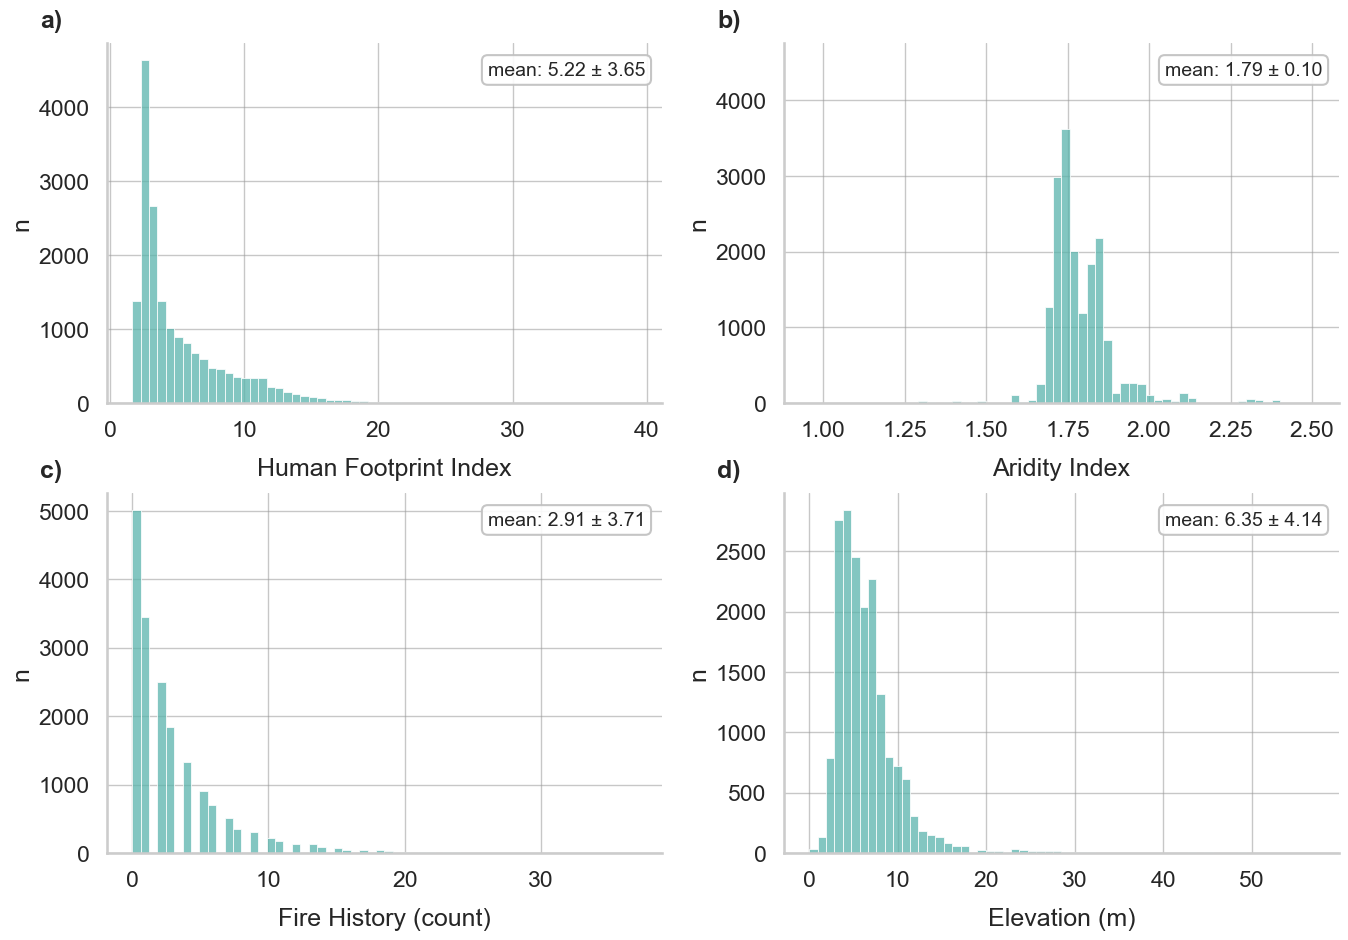

In [40]:
plot_histogram_panel(
    first_group_predictors,
    filename="histogram_panel_pt1.png",
    panel_labels=["a)", "b)", "c)", "d)"],
)

Saved: figures/histogram_panel_pt2.png


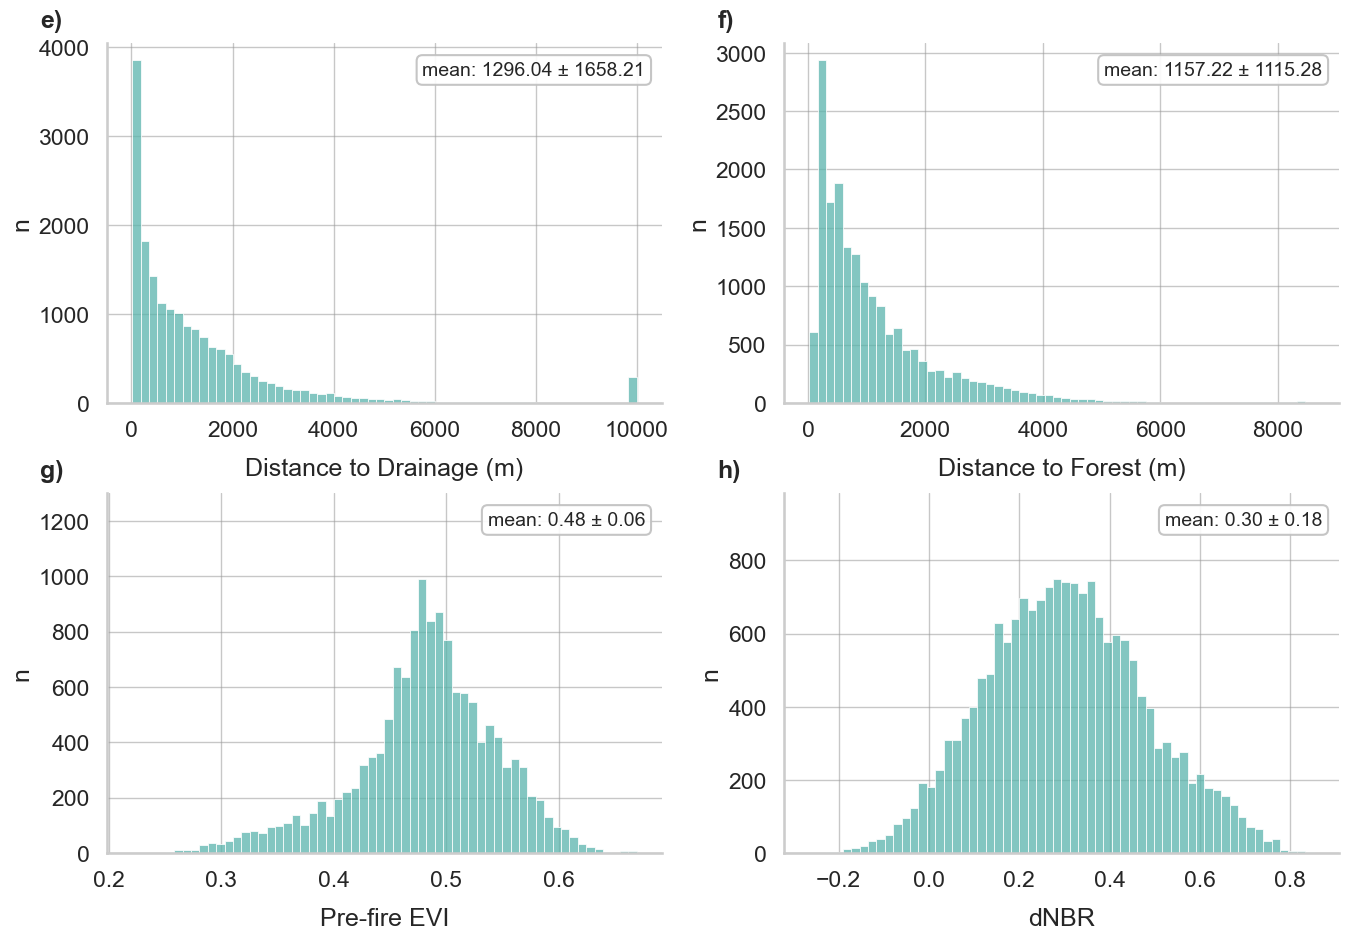

In [41]:
plot_histogram_panel(
    second_group_predictors,
    filename="histogram_panel_pt2.png",
    panel_labels=["e)", "f)", "g)", "h)"],
)

## Model fitting

In [12]:
# make list with predictor column names
predictor_cols = df.columns.to_list()[2:-2]
predictor_cols

['hfp',
 'drainage_dist',
 'forest_dist',
 'pre_fire_evi',
 'aridity_index',
 'fire_history',
 'dnbr',
 'elevation']

In [13]:
# set up predictors = response
X = df[predictor_cols]
y_2y = df.recovery_2y
y_5y = df.recovery_5y

In [14]:
# hyperparameter tuning

# takes very long (>20 min), so only do if absolutely necessary!
redo_tuning = False

if redo_tuning:
    
    param_grid = {
        "n_estimators": [200, 400, 600, 800],
        "max_features": [2, 3, 4, 5]
    }
    
    rf = RandomForestRegressor(random_state=42)
    
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    
    grid = GridSearchCV(
        rf,
        param_grid,
        cv=kf,
        scoring="r2",
        n_jobs=4
    )
    
    grid.fit(X, y_2y)
    
    print("2-year recovery")
    print(grid.best_params_)
    print(grid.best_score_)
    
    rf = RandomForestRegressor(random_state=42)
    
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    
    grid = GridSearchCV(
        rf,
        param_grid,
        cv=kf,
        scoring="r2",
        n_jobs=4
    )
    
    grid.fit(X, y_5y)
    
    print("5-year recovery")
    print(grid.best_params_)
    print(grid.best_score_)

In [15]:
# prepare 10-fold cross-validation (CV)

kf = KFold(n_splits=10, 
           shuffle=True, # randomly shuffle order before making folds
           random_state=42)

In [16]:
# prepare models

rf_2y = RandomForestRegressor(
    n_estimators=800, # number of trees (optimal value from GridSearch)
    max_features=4, # number of features at each split (optimal value from GridSearch)
    random_state=42,
    n_jobs=4
)

rf_5y = RandomForestRegressor(
    n_estimators=800,
    max_features=4,  
    random_state=42,
    n_jobs=4
)

In [17]:
# predict per fold (out of box)

# empty lists for recording per-fold accuracy metrics
r2_2y = []
rmse_2y = []
r2_5y = []
rmse_5y = []

# add columns for prediction in dataframe
df['pred_2y'] = np.nan
df['pred_5y'] = np.nan

# loop through folds
for train_idx, test_idx in kf.split(X):

    # subset dataframe to just one fold and split train/test
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train_2y, y_test_2y = y_2y.iloc[train_idx], y_2y.iloc[test_idx]
    y_train_5y, y_test_5y = y_5y.iloc[train_idx], y_5y.iloc[test_idx]

    # train on 9 training folds
    rf_2y.fit(X_train, y_train_2y)
    rf_5y.fit(X_train, y_train_5y)

    # predict for current validation fold
    pred_2y = rf_2y.predict(X_test)
    pred_5y = rf_5y.predict(X_test)

    # add prediction to dataframe
    df.iloc[test_idx, df.columns.get_loc('pred_2y')] = pred_2y
    df.iloc[test_idx, df.columns.get_loc('pred_5y')] = pred_5y

    # add metrics to list
    r2_2y.append(r2_score(y_test_2y, pred_2y))
    rmse_2y.append(np.sqrt(mean_squared_error(y_test_2y, pred_2y)))
    r2_5y.append(r2_score(y_test_5y, pred_5y))
    rmse_5y.append(np.sqrt(mean_squared_error(y_test_5y, pred_5y)))

## Model accuracy

In [18]:
# 2 year
print("2-year recovery rate prediction")
print('Mean R2:', round(np.mean(r2_2y),2))
print('SD R2:', round(np.std(r2_2y),2))

print('Mean RMSE:', round(np.mean(rmse_2y),2))
print('SD RMSE:', round(np.std(rmse_2y),2))

2-year recovery rate prediction
Mean R2: 0.56
SD R2: 0.02
Mean RMSE: 16.07
SD RMSE: 0.54


In [19]:
# 5 year
print("5-year recovery rate prediction")
print('Mean R2:', round(np.mean(r2_5y),2))
print('SD R2:', round(np.std(r2_5y),2))

print('Mean RMSE:', round(np.mean(rmse_5y),2))
print('SD RMSE:', round(np.std(rmse_5y),2))

5-year recovery rate prediction
Mean R2: 0.52
SD R2: 0.02
Mean RMSE: 17.69
SD RMSE: 0.42


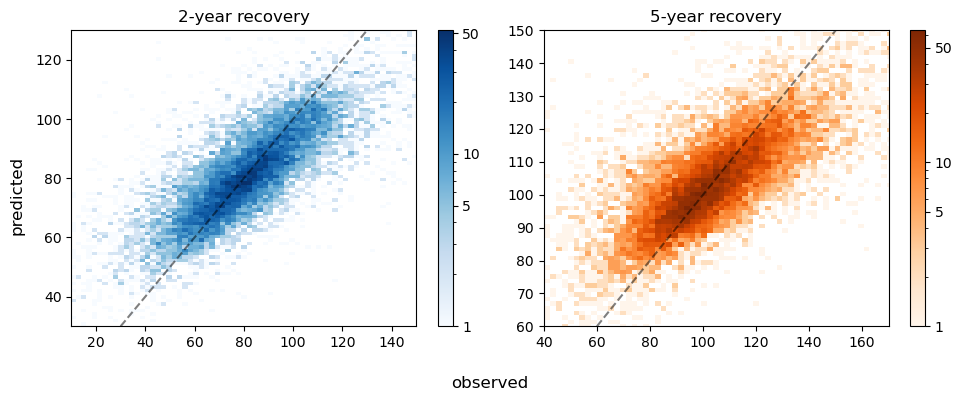

In [20]:
# observed vs. predicted

from matplotlib.colors import LogNorm

fig, axs = plt.subplots(ncols=2, figsize=(10,4))

# 2 years
p1 = axs[0].hist2d(
    x=df.recovery_2y, y=df.pred_2y, 
    bins=(150, 150), 
    norm=LogNorm(),
    cmap='Blues')
axs[0].set_title('2-year recovery')
axs[0].axline(xy1=(0,0), slope=1, color='black', linestyle='--', alpha=.5)
axs[0].set_xlim(10,150)
axs[0].set_ylim(30,130)

# colorbar
cbar1 = fig.colorbar(p1[3], ax=axs[0])
# cbar1.set_label("n")
ticks = [1, 5, 10, 50]
cbar1.set_ticks(ticks)
cbar1.set_ticklabels(ticks)

# 5 years
p2 = axs[1].hist2d(x=df.recovery_5y, y=df.pred_5y, 
              bins=(150, 150), 
              norm=LogNorm(),
              cmap='Oranges')
axs[1].set_title('5-year recovery')
axs[1].axline(xy1=(0,0), slope=1, color='black', linestyle='--', alpha=.5)
axs[1].set_xlim(40,170)
axs[1].set_ylim(60,150)

# colorbar
cbar2 = fig.colorbar(p2[3], ax=axs[1])
# cbar2.set_label("Number of observations")
ticks = [1, 5, 10, 50]
cbar2.set_ticks(ticks)
cbar2.set_ticklabels(ticks)

# labels
fig.supxlabel('observed', x=0.5)
fig.supylabel('predicted')

plt.tight_layout()
# plt.show()
plt.savefig('figures/obs-vs-pred.png', dpi=300, bbox_inches='tight')

## Residual analysis

In [21]:
# calculate residuals
df['resid_2y'] = df.recovery_2y - df.pred_2y
df['resid_5y'] = df.recovery_5y - df.pred_5y

In [22]:
df[['resid_2y', 'resid_5y']].describe()

,resid_2y,resid_5y
count,13981.000000,13981.000000
mean,-0.009621,-0.142250
std,16.080564,17.691588
min,-141.769153,-174.616860
25%,-7.423970,-8.304460
50%,0.391286,-0.457184
75%,7.536602,7.721811
max,128.820227,166.072734


In [23]:
# calculate bias
bias_2y = np.mean(df.resid_2y)
print('Bias 2-year recovery: ', bias_2y)

bias_5y = np.mean(df.resid_5y)
print('Bias 5-year recovery: ', bias_5y)

Bias 2-year recovery:  -0.009620677928625249
Bias 5-year recovery:  -0.1422496954468842


<Axes: >

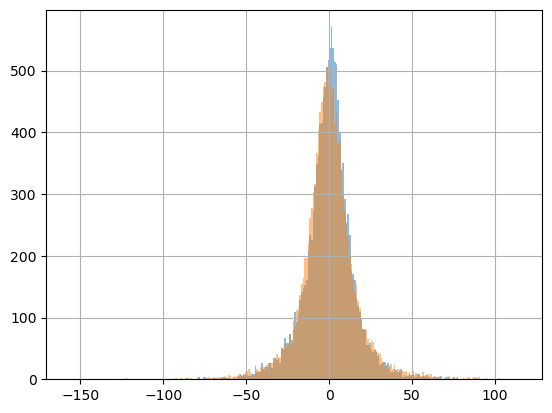

In [24]:
df.resid_2y.hist(bins=np.arange(-157, 116, 1),alpha=.5)
df.resid_5y.hist(bins=np.arange(-157, 116, 1),alpha=.5)

In [25]:
np.corrcoef(df.recovery_2y, df.pred_2y)

array([[1.        , 0.75674425],
       [0.75674425, 1.        ]])

In [26]:
np.corrcoef(df.recovery_5y, df.pred_5y)

array([[1.        , 0.73062093],
       [0.73062093, 1.        ]])

## Variable importance

In [27]:
# train models on full data (for next steps)
rf_2y.fit(X, y_2y)
rf_5y.fit(X, y_5y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",800
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",4
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [28]:
# 2 years
importances_2y = rf_2y.feature_importances_

importance_df_2y = pd.DataFrame({
    "variable": X.columns,
    "importance": importances_2y
}).sort_values("importance", ascending=False)

importance_df_2y

,variable,importance
4,aridity_index,0.190561
1,drainage_dist,0.170518
3,pre_fire_evi,0.151193
0,hfp,0.145459
6,dnbr,0.128210
2,forest_dist,0.096155
7,elevation,0.072661
5,fire_history,0.045242


In [29]:
# 5 years
importances_5y = rf_5y.feature_importances_

importance_df_5y = pd.DataFrame({
    "variable": X.columns,
    "importance": importances_5y
}).sort_values("importance", ascending=False)

importance_df_5y

,variable,importance
4,aridity_index,0.192199
3,pre_fire_evi,0.153680
1,drainage_dist,0.144589
0,hfp,0.142691
6,dnbr,0.134877
2,forest_dist,0.111641
7,elevation,0.071167
5,fire_history,0.049156


In [30]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(rf_2y, X, y_2y, n_repeats=10, random_state=42)

perm_imp_2y = pd.DataFrame({
    "variable": X.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

perm_imp_2y

,variable,importance
1,drainage_dist,0.521539
3,pre_fire_evi,0.483042
4,aridity_index,0.474695
0,hfp,0.427028
6,dnbr,0.314065
7,elevation,0.232337
2,forest_dist,0.162417
5,fire_history,0.072881


In [31]:
perm = permutation_importance(rf_5y, X, y_5y, n_repeats=10, random_state=42)

perm_imp_5y = pd.DataFrame({
    "variable": X.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

perm_imp_5y

,variable,importance
4,aridity_index,0.628971
1,drainage_dist,0.470492
0,hfp,0.439973
3,pre_fire_evi,0.431024
6,dnbr,0.314899
2,forest_dist,0.189168
7,elevation,0.150625
5,fire_history,0.096367


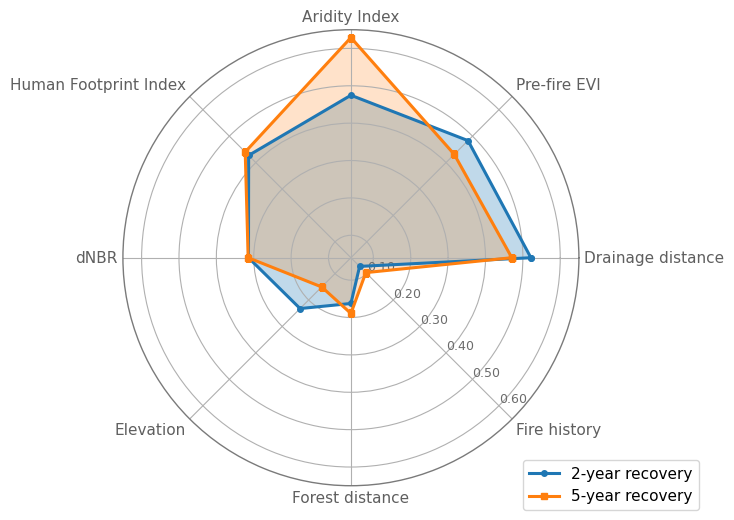

In [32]:
# radial plot for permutation importance

vars_order = perm_imp_2y["variable"].tolist()
radar_labels = {
    "hfp": "Human Footprint Index",
    "drainage_dist": "Drainage distance",
    "forest_dist": "Forest distance",
    "pre_fire_evi": "Pre-fire EVI",
    "aridity_index": "Aridity Index",
    "fire_history": "Fire history",
    "dnbr": "dNBR",
    "elevation": "Elevation",
}
display_labels = [radar_labels.get(var, var) for var in vars_order]

imp2 = perm_imp_2y.set_index("variable").loc[vars_order, "importance"].values
imp5 = perm_imp_5y.set_index("variable").loc[vars_order, "importance"].values

angles = np.linspace(0, 2 * np.pi, len(vars_order), endpoint=False)
closed_angles = np.concatenate([angles, [angles[0]]])
imp2 = np.concatenate([imp2, [imp2[0]]])
imp5 = np.concatenate([imp5, [imp5[0]]])

blue_color = 'tab:blue' #"#2f83cc"
red_color = 'tab:orange' #'orange' # "#d84b4b"
max_radius = 0.65
label_radius = max_radius + 0.014

fig, ax = plt.subplots(
    figsize=(6, 6),
    subplot_kw={"polar": True},
)

ax.plot(closed_angles, imp2, color=blue_color, linewidth=2.2, marker="o", markersize=4, label="2-year recovery")
ax.fill(closed_angles, imp2, color=blue_color, alpha=0.28)

ax.plot(closed_angles, imp5, color=red_color, linewidth=2.2, marker="s", markersize=4, label="5-year recovery")
ax.fill(closed_angles, imp5, color=red_color, alpha=0.22)

ax.set_xticks(angles)
ax.set_xticklabels([])

#Labels out of the plot 
for angle, label in zip(angles, display_labels):
    cos_val = np.cos(angle)
    sin_val = np.sin(angle)

    if cos_val > 0.15:
        ha = "left"
    elif cos_val < -0.15:
        ha = "right"
    else:
        ha = "center"

    if sin_val > 0.85:
        va = "bottom"
    elif sin_val > 0.25:
        va = "bottom"
    elif sin_val < -0.25:
        va = "top"
    else:
        va = "center"

    ax.text(
        angle,
        label_radius,
        label,
        fontsize=11,
        color="#5f5f5f",
        ha=ha,
        va=va,
        clip_on=False,
    )

ax.set_ylim(0.04, max_radius)
radial_ticks = np.arange(0.1, 0.7, 0.1)
ax.set_yticks(radial_ticks)
ax.set_yticklabels([f"{tick:.2f}" for tick in radial_ticks], fontsize=9, color="#6b6b6b")
fire_history_angle = angles[vars_order.index("fire_history")]
ax.set_rlabel_position(np.degrees(fire_history_angle))

ax.spines["polar"].set_color("#7a7a7a")
ax.spines["polar"].set_linewidth(1.0)

# ax.set_title("Permutation", pad=44, fontsize=15, color="#4f4f4f")
legend = ax.legend(loc="lower right", bbox_to_anchor=(1.28, -0.07), frameon=True, fontsize=11)
legend.get_frame().set_linewidth(1.0)

fig.subplots_adjust(left=0.05, right=0.83, top=0.84, bottom=0.08)
# plt.show()
plt.savefig('figures/perm_imp.png', dpi=300, bbox_inches='tight')

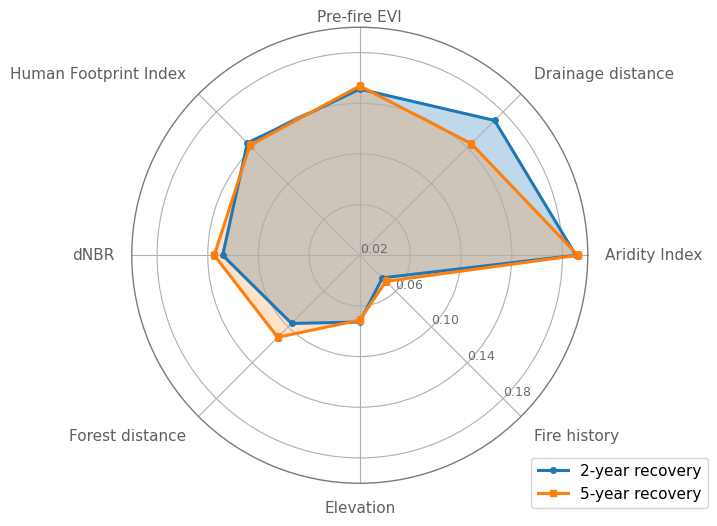

In [33]:
# same for impurity importance

vars_order = importance_df_2y["variable"].tolist()
radar_labels = {
    "hfp": "Human Footprint Index",
    "drainage_dist": "Drainage distance",
    "forest_dist": "Forest distance",
    "pre_fire_evi": "Pre-fire EVI",
    "aridity_index": "Aridity Index",
    "fire_history": "Fire history",
    "dnbr": "dNBR",
    "elevation": "Elevation",
}
display_labels = [radar_labels.get(var, var) for var in vars_order]

imp2 = importance_df_2y.set_index("variable").loc[vars_order, "importance"].values
imp5 = importance_df_5y.set_index("variable").loc[vars_order, "importance"].values

angles = np.linspace(0, 2 * np.pi, len(vars_order), endpoint=False)
closed_angles = np.concatenate([angles, [angles[0]]])
imp2 = np.concatenate([imp2, [imp2[0]]])
imp5 = np.concatenate([imp5, [imp5[0]]])

blue_color = 'tab:blue' #"#2f83cc"
red_color = 'tab:orange' #'orange' # "#d84b4b"
max_radius = 0.20
label_radius = max_radius + 0.014

fig, ax = plt.subplots(
    figsize=(6, 6),
    subplot_kw={"polar": True},
)

ax.plot(closed_angles, imp2, color=blue_color, linewidth=2.2, marker="o", markersize=4, label="2-year recovery")
ax.fill(closed_angles, imp2, color=blue_color, alpha=0.28)

ax.plot(closed_angles, imp5, color=red_color, linewidth=2.2, marker="s", markersize=4, label="5-year recovery")
ax.fill(closed_angles, imp5, color=red_color, alpha=0.22)

ax.set_xticks(angles)
ax.set_xticklabels([])

#Labels out of the plot 

for angle, label in zip(angles, display_labels):
    cos_val = np.cos(angle)
    sin_val = np.sin(angle)

    if cos_val > 0.15:
        ha = "left"
    elif cos_val < -0.15:
        ha = "right"
    else:
        ha = "center"

    if sin_val > 0.85:
        va = "top"
    elif sin_val > 0.25:
        va = "bottom"
    elif sin_val < -0.25:
        va = "top"
    else:
        va = "center"

    ax.text(
        angle,
        label_radius,
        label,
        fontsize=11,
        color="#5f5f5f",
        ha=ha,
        va=va,
        clip_on=False,
    )

ax.set_ylim(0.04, max_radius)
radial_ticks = [0.02, 0.06, 0.10, 0.14, 0.18]
ax.set_yticks(radial_ticks)
ax.set_yticklabels([f"{tick:.2f}" for tick in radial_ticks], fontsize=9, color="#6b6b6b")
fire_history_angle = angles[vars_order.index("fire_history")]
ax.set_rlabel_position(np.degrees(fire_history_angle))

ax.spines["polar"].set_color("#7a7a7a")
ax.spines["polar"].set_linewidth(1.0)

# ax.set_title("Impurity", pad=44, fontsize=15, color="#4f4f4f")
legend = ax.legend(loc="lower right", bbox_to_anchor=(1.28, -0.07), frameon=True, fontsize=11)
legend.get_frame().set_linewidth(1.0)

fig.subplots_adjust(left=0.05, right=0.83, top=0.84, bottom=0.08)
# plt.show()
plt.savefig('figures/impurity_imp.png', dpi=300, bbox_inches='tight')

## Variable effects

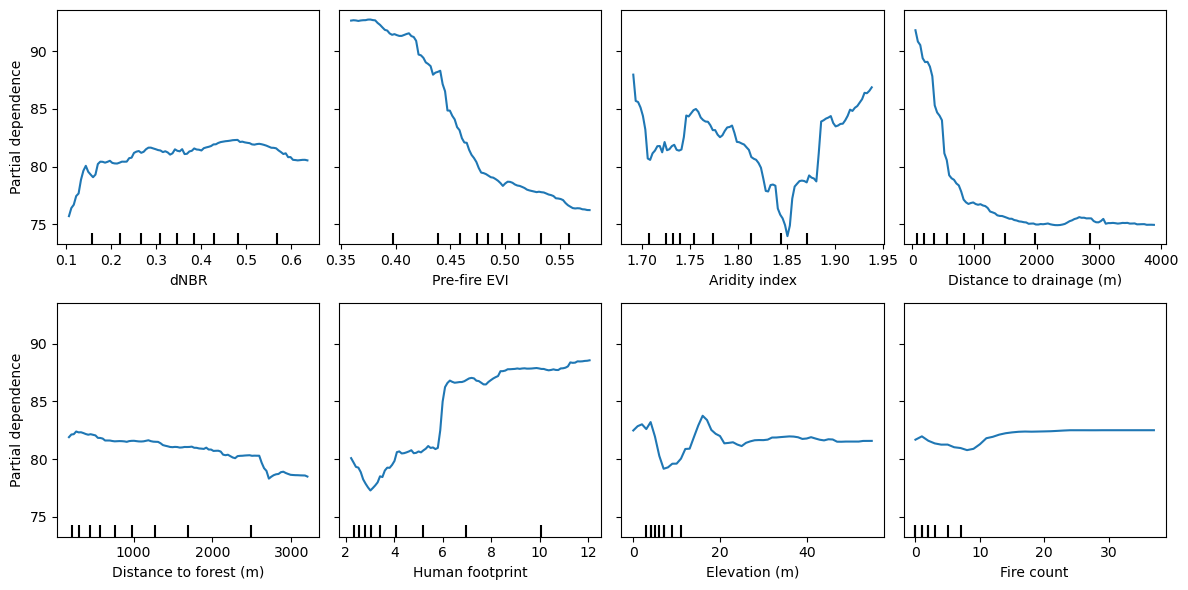

In [35]:
# 2 years

fig, axs = plt.subplots(2, 4, figsize=(12, 6))  # adjust as needed

pdp_2y = PartialDependenceDisplay.from_estimator(
    rf_2y,
    X.astype(float),
    ['dnbr', 'pre_fire_evi', 'aridity_index', 'drainage_dist', 'forest_dist', 'hfp', 'elevation', 'fire_history'],
    ax=axs
)

# custom labels
labels = [
    'dNBR',
    'Pre-fire EVI',
    'Aridity index',
    'Distance to drainage (m)',
    'Distance to forest (m)',
    'Human footprint',
    'Elevation (m)',
    'Fire count'
]

for ax, label in zip(pdp_2y.axes_.ravel(), labels):
    ax.set_xlabel(label)

plt.tight_layout()
# plt.show()
plt.savefig('figures/pdp_2y.png', dpi=300, bbox_inches='tight')

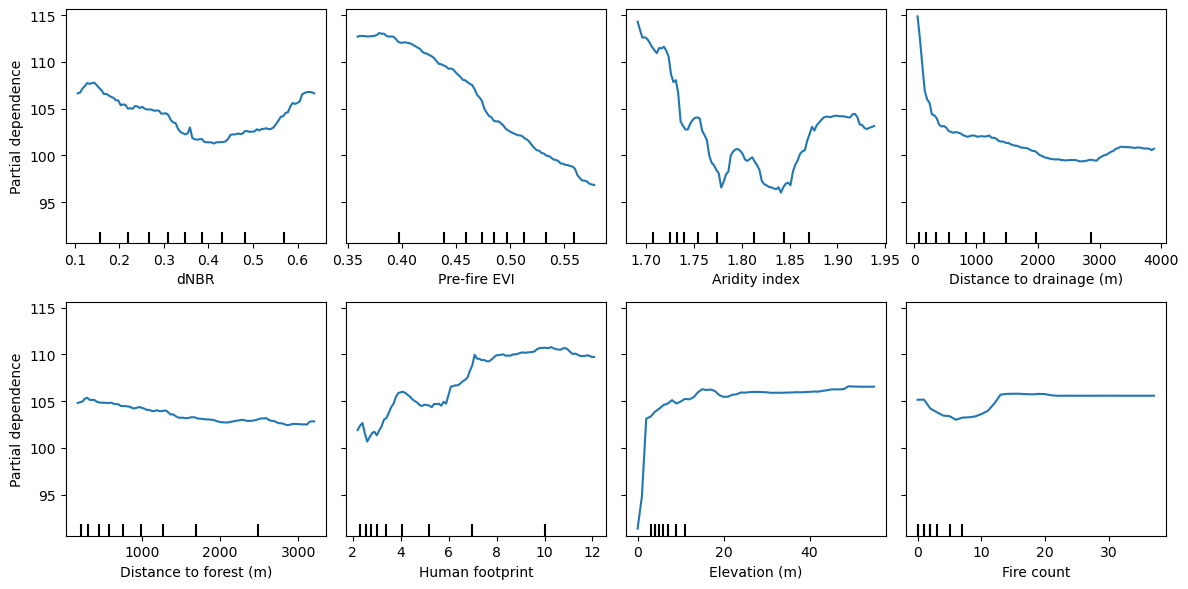

In [36]:
# 5 years

fig, axs = plt.subplots(2, 4, figsize=(12, 6))  # adjust as needed

pdp_5y = PartialDependenceDisplay.from_estimator(
    rf_5y,
    X.astype(float),
    ['dnbr', 'pre_fire_evi', 'aridity_index', 'drainage_dist', 'forest_dist', 'hfp', 'elevation', 'fire_history'],
    ax=axs
)

# modify x-axis labels
for ax, label in zip(pdp_5y.axes_.ravel(), labels):
    ax.set_xlabel(label)
    
plt.tight_layout()
# plt.show()
plt.savefig('figures/pdp_5y.png', dpi=300, bbox_inches='tight')

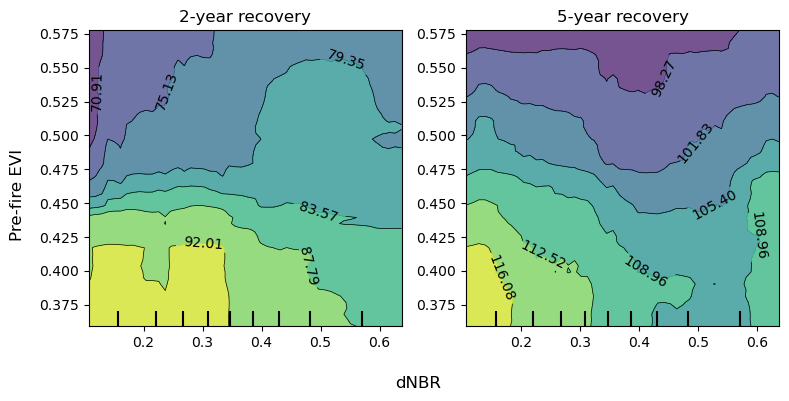

In [37]:
# 2D plot (effect of dNBR and pre-fire EVI at the same time)

fig, axs = plt.subplots(ncols=2, figsize=(8,4))

p1 = PartialDependenceDisplay.from_estimator(
    rf_2y,                 # trained random forest
    X,                  # predictors dataframe
    features=[('dnbr','pre_fire_evi')],  # the pair of variables
    grid_resolution=50,
    ax=axs[0]
)

p2 = PartialDependenceDisplay.from_estimator(
    rf_5y,                 # trained random forest
    X,                  # predictors dataframe
    features=[('dnbr','pre_fire_evi')],  # the pair of variables
    grid_resolution=50,
    ax=axs[1]
)

p1.axes_[0,0].set_xlabel('')
p1.axes_[0,0].set_ylabel('')
p2.axes_[0,0].set_xlabel('')
p2.axes_[0,0].set_ylabel('')

fig.supxlabel('dNBR', x=0.53)
fig.supylabel('Pre-fire EVI')

axs[0].set_title('2-year recovery')
axs[1].set_title('5-year recovery')

plt.tight_layout()
# plt.show()
plt.savefig('figures/pdp_2d.png', dpi=300, bbox_inches='tight')